In [ ]:
import cv2
import numpy as np

def resize_and_pad(image: cv2.Mat, target_size: tuple) -> cv2.Mat:
    height, width = image.shape[:2]
    center = np.array(image.shape[:2]) / 2
    
    # Get smallest side to determine the crop size
    crop = min(height, width)
    x = center[1] - crop / 2
    y = center[0] - crop / 2

    img_cropped = image[int(y):int(y+crop), int(x):int(x+crop)]

    # Crop the image to a square
    img_cropped = cv2.resize(img_cropped, target_size, interpolation=cv2.INTER_AREA)

    return img_cropped


## Generate Grayscale Images

In [ ]:
import os, cv2

CATEGORY_LABELS = ['.']
SIZE = 224
SOURCE_IMAGE_DIR = ".data/eval/"
RGB_IMAGE_DIR = f".data/eval_rgb_{SIZE}/"

total_samples = 0

for img_dir in CATEGORY_LABELS:
    sample_count = len(os.listdir(os.path.join(SOURCE_IMAGE_DIR, img_dir)))
    print(f"Processing category: {img_dir} ({sample_count} samples)")
    total_samples += sample_count

    for filename in os.listdir(os.path.join(SOURCE_IMAGE_DIR, img_dir)):
        if not (filename.endswith(".jpg") or filename.endswith(".png")): continue
        
        # Processing
        img = cv2.imread(os.path.join(SOURCE_IMAGE_DIR, img_dir, filename), cv2.IMREAD_COLOR_RGB)
        img_resized = resize_and_pad(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), target_size=(SIZE, SIZE))

        rgb_dir = os.path.join(RGB_IMAGE_DIR, f"{img_dir}")
        os.makedirs(rgb_dir, exist_ok=True)
        cv2.imwrite(os.path.join(rgb_dir, filename), img_resized)

        del img, img_resized

print("----------------------------------------")
print(f"Total samples processed: {total_samples}")

PREDICTION RESULTS:
------------------------------
0. not_food: 1.0000
1. italian_food: 0.0000
2. japanese_food: 0.0000
3. fast_food: 0.0000
4. meat: 0.0000
5. seafood: 0.0000
6. soup: 0.0000
7. salad: 0.0000
8. dessert: 0.0000
9. rice: 0.0000
10. eggs: 0.0000
------------------------------

PREDICTION: not_food


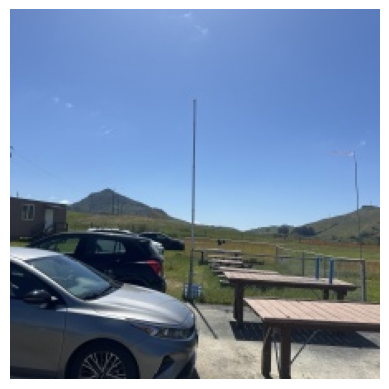

In [ ]:
import os, cv2, time, json
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from IPython.display import Image, display, clear_output
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from cnn import ResNet, Bottleneck


EVAL_IMAGE = "/home/marked01one/Programming/school/ECE4990/final_project/training/.data/eval_rgb_224/PXL_20251215_070410767.jpg"

CATEGORY_LABELS = [
    "not_food",
    "italian_food",
    "japanese_food",
    "fast_food",
    "meat",
    "seafood",
    "soup",
    "salad",
    "dessert",
    "rice",
    "eggs",
]

TP, TN, FP, FN = 0, 0, 0, 0


# net = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=len(CATEGORY_LABELS), num_channels=3)
# net.load_state_dict(torch.load("../models/resnet_food_classifier_big_epoch_20.pth", weights_only=True))
# net.eval()
#  
# scripted = torch.jit.trace(net, torch.rand(1, 3, 224, 224))
# scripted.save("resnet_food_epoch_20.pt")

model = torch.jit.load("../models/resnet_food_epoch_20.pt")
model.eval()

image_file = cv2.imread(EVAL_IMAGE, cv2.IMREAD_COLOR_RGB).transpose(2, 0, 1) / 255.0  # Convert to CHW format and normalize

with torch.no_grad():
    tensor = torch.tensor(np.array(image_file), dtype=torch.float32).unsqueeze(0) # Add batch and channel dimensions
    prediction = model(tensor)
    probabilities = F.softmax(prediction, dim=1).numpy()[0]
        


print("PREDICTION RESULTS:")
print("------------------------------")
for idx, (label, prob) in enumerate(zip(CATEGORY_LABELS, probabilities)):
    print(f"{idx}. {label}: {prob:.4f}")

selected_label = CATEGORY_LABELS[np.argmax(probabilities)]
print("------------------------------")
print(f"\nPREDICTION: {selected_label}")

plt.axis('off')
plt.imshow(image_file.transpose(1, 2, 0))

## Appendix: Image Labeling

In [ ]:
import json, os
from IPython.display import Image, display, clear_output

EVAL_IMAGE_DIR = ".data/eval_rgb_224/"
EVAL_IMAGE_METADATA_PATH = os.path.join(EVAL_IMAGE_DIR, ".labels.json")

label_file = open(EVAL_IMAGE_METADATA_PATH, "r")
eval_image_labels = json.load(label_file)
label_file.close()

eval_images = [img for img in sorted(os.listdir(EVAL_IMAGE_DIR)) if not img.endswith(".json")]

for img_path in eval_images:
    if img_path in eval_image_labels: continue  # Skip if label already exists
    display(Image(os.path.join(EVAL_IMAGE_DIR, img_path)))
    
    try:
        label = input("image label: ").strip().lower()
        assert label in CATEGORY_LABELS, f"Invalid label. Please enter one of the following: {', '.join(CATEGORY_LABELS)}"
        eval_image_labels[img_path] = label
        clear_output(wait=True)
    
    except AssertionError as e:
        label_file = open(EVAL_IMAGE_METADATA_PATH, "w")
        json.dump(eval_image_labels, label_file, indent=4)
        label_file.close()
        raise e

label_file = open(EVAL_IMAGE_METADATA_PATH, "w")
print("All images labeled. Saving labels to file.") 
json.dump(eval_image_labels, label_file, indent=4)
label_file.close()
